# GDELT BigQuery

The `GoldsteinScale` and `AvgTone` values are raw scores directly available in the GDELT (Global Database of Events, Language, and Tone) dataset, specifically from the `gdelt-bq.full.events` table, as shown in the SQL query in the notebook:

```sql
SELECT
    ...
    GoldsteinScale AS goldstein,
    AvgTone AS tone
FROM `gdelt-bq.full.events`
WHERE ...
```

Here's what each represents:

-   **GoldsteinScale**: This is an automatically generated numeric score that quantifies the **intensity of cooperation or conflict** between two actors in an event. It typically ranges from -10 to +10.
    -   Higher positive values (e.g., +10) indicate highly cooperative interactions (e.g., formal alliance, binding arbitration).
    -   Lower negative values (e.g., -10) indicate highly conflictual interactions (e.g., conventional warfare, genocide).
    -   A score around 0 indicates neutral or less intense interactions.
    The specific algorithm for calculating the GoldsteinScale is detailed in GDELT's event codebook, but generally, it's mapped to the CAMEO (Conflict and Mediation Event Observations) event codes.

-   **AvgTone**: This is a numeric score that measures the **average tone or sentiment** of the source document(s) referring to an event. It typically ranges from -10 to +10:
    -   Positive values (e.g., +10) suggest a highly positive tone (e.g., happiness, progress, agreement).
    -   Negative values (e.g., -10) suggest a highly negative tone (e.g., anger, criticism, violence).
    -   A score around 0 indicates a neutral tone.
    The `AvgTone` is computed using a dictionary-based sentiment analysis algorithm applied to the text of news articles and other sources monitored by GDELT. It reflects the overall emotional valence of the reporting surrounding an event, not necessarily the actual outcome of the event itself.

After extracting these raw scores, the notebook then calculates `goldstein_avg` and `tone_avg` by taking the average of these `GoldsteinScale` and `AvgTone` values, respectively, grouped by country, year, and category, and weighted by `event_count`.

The notebook calculates a **Z-score** for `conflict_events` and `coop_events` within each country to understand how much an event count deviates from the country's average event count, relative to its variability.

The `zscore` function is defined as follows:

```python
def zscore(series):
    s = series.astype(float)
    std = s.std(ddof=0) # ddof=0 calculates the population standard deviation
    if std == 0 or np.isnan(std):
        return pd.Series([0.0] * len(s), index=s.index)
    return (s - s.mean()) / std
```

Here's a breakdown:

1.  **`s = series.astype(float)`**: Ensures the input series (e.g., `conflict_events` for a specific country) is treated as floating-point numbers.
2.  **`std = s.std(ddof=0)`**: Calculates the standard deviation of the event counts for that country. `ddof=0` specifies that it's computing the **population standard deviation**, meaning it divides by `N` instead of `N-1` (which is typically used for sample standard deviation). This is appropriate when you consider all available data for a country as its population of events over the observed period.
3.  **`if std == 0 or np.isnan(std): return pd.Series([0.0] * len(s), index=s.index)`**: This handles edge cases where the standard deviation is zero (meaning all values in the series are the same) or not a number. In such cases, a z-score of 0.0 is returned, implying no deviation.
4.  **`return (s - s.mean()) / std`**: This is the core z-score formula:
    -   `(s - s.mean())`: Calculates the difference between each event count and the mean (average) event count for that country.
    -   `/ std`: Divides this difference by the standard deviation. This normalizes the deviation, making it comparable across different countries and event types.

### Application in the Notebook:

-   **`conflict_events_z`**: The z-score is calculated for `conflict_events` for each country over its `year_window`s. A positive z-score means the number of conflict events in that window is above the country's average, and a negative z-score means it's below average. The magnitude indicates how many standard deviations away it is.

-   **`conflict_spike_hi` and `conflict_spike_med`**: These are binary indicators derived directly from `conflict_events_z`:
    -   `conflict_spike_hi`: Set to 1 if `conflict_events_z` is greater than 1.5, indicating a

The `goldstein_avg` and `tone_avg` are calculated as **weighted averages** based on the `event_count` for each `goldstein` and `tone` value within a specific country, year, and category.

Let's break down the logic used in the `weighted_mean` function:

```python
def weighted_mean(values, weights):
    v = np.array(values, dtype=float)  # Convert values to a float numpy array
    w = np.array(weights, dtype=float)  # Convert weights to a float numpy array
    if w.sum() == 0:  # Check if the sum of weights is zero to avoid division by zero
        return np.nan  # Return NaN if there are no weights
    return (v * w).sum() / w.sum()  # Calculate the weighted mean
```

- `values`: This refers to the `goldstein_avg` or `tone_avg` for a given country-year-category combination *before* the final aggregation. Effectively, these are the average GoldsteinScale or AvgTone values for events within a specific year, for a specific country and category.
- `weights`: This refers to the `event_count` for that specific country, year, and category.

So, when `gdelt_country_window_category` is calculated:

- `goldstein_wavg`: For each `iso3`, `year_window`, and `category`, it takes the `goldstein_avg` values from the individual years within that window (e.g., 1996-2000 for `year_window` 2000) and calculates a weighted average. The weights are the `event_count` for each of those individual year entries. This ensures that years with more events contribute more to the overall average goldstein score for that window and category.

- `tone_wavg`: The same logic applies to `tone_wavg`, using `tone_avg` values weighted by `event_count`.

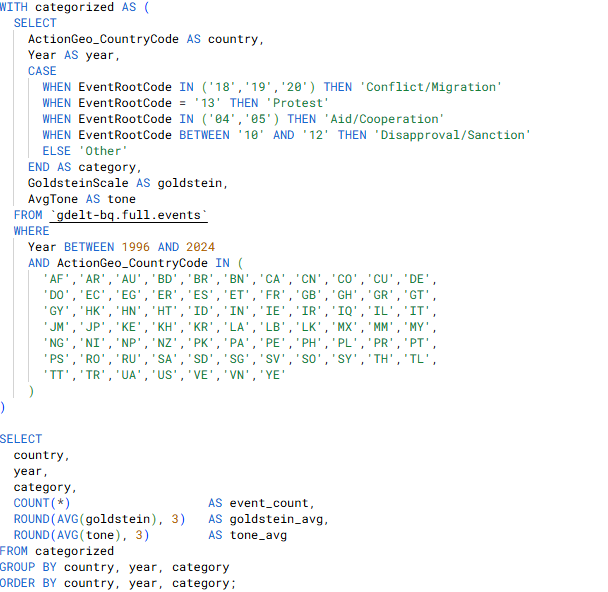

-- Full geopolitical extraction for BOTH origin and destination countries
-- Period: 2000–2024, Categories = Conflict/Migration, Protest, Aid, Disapproval, Other

WITH categorized AS (
  SELECT
    ActionGeo_CountryCode AS country,
    Year AS year,
    CASE
      WHEN EventRootCode IN ('18','19','20') THEN 'Conflict/Migration'
      WHEN EventRootCode = '13' THEN 'Protest'
      WHEN EventRootCode IN ('04','05') THEN 'Aid/Cooperation'
      WHEN EventRootCode BETWEEN '10' AND '12' THEN 'Disapproval/Sanction'
      ELSE 'Other'
    END AS category,
    GoldsteinScale AS goldstein,
    AvgTone AS tone
  FROM `gdelt-bq.full.events`
  WHERE
    Year BETWEEN 1996 AND 2024



    AND ActionGeo_CountryCode IN (
      'AF','AR','AU','BD','BR','BN','CA','CN','CO','CU','DE',
      'DO','EC','EG','ER','ES','ET','FR','GB','GH','GR','GT',
      'GY','HK','HN','HT','ID','IN','IE','IR','IQ','IL','IT',
      'JM','JP','KE','KH','KR','LA','LB','LK','MX','MM','MY',
      'NG','NI','NP','NZ','PK','PA','PE','PH','PL','PR','PT',
      'PS','RO','RU','SA','SD','SG','SV','SO','SY','TH','TL',
      'TT','TR','UA','US','VE','VN','YE'
    )
)

SELECT
  country,
  year,
  category,
  COUNT(*)                   AS event_count,
  ROUND(AVG(goldstein), 3)   AS goldstein_avg,
  ROUND(AVG(tone), 3)        AS tone_avg
FROM categorized
GROUP BY country, year, category
ORDER BY country, year, category;

# **GDELT**

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pycountry

import pandas as pd
import numpy as np
import pycountry

In [ ]:
gdelt = pd.read_csv("/content/drive/MyDrive/FYP/data/raw/gdelt_country_year_category.csv")
gdelt.head(), gdelt.columns, gdelt.dtypes

(  country  year              category  event_count  goldstein_avg  tone_avg
 0      AF  1996       Aid/Cooperation        11059          3.429     5.219
 1      AF  1996    Conflict/Migration         4606         -9.875     3.322
 2      AF  1996  Disapproval/Sanction         2269         -3.150     4.703
 3      AF  1996                 Other         9605          2.027     4.869
 4      AF  1996               Protest          473         -5.585     4.402,
 Index(['country', 'year', 'category', 'event_count', 'goldstein_avg',
        'tone_avg'],
       dtype='object'),
 country           object
 year               int64
 category          object
 event_count        int64
 goldstein_avg    float64
 tone_avg         float64
 dtype: object)

validation checks

In [ ]:
# 1. Year range
print("Year range:", gdelt["year"].min(), "→", gdelt["year"].max())

# 2. Few random rows for sanity
print("\nSample rows:")
display(gdelt.sample(10))

# 3. Nulls per column
print("\nMissing values per column:")
print(gdelt.isna().sum())

# 4. Unique categories
print("\nExample categories:")
print(gdelt["category"].dropna().unique()[:20])

# 5. Countries sample
print("\nCountry codes:")
print(gdelt["country"].dropna().unique())

Year range: 1996 → 2024

Sample rows:


,country,year,category,event_count,goldstein_avg,tone_avg
4983,NI,2008,Protest,1373,-5.295,5.197
6038,PS,2018,Conflict/Migration,94,-9.904,-0.761
1989,ER,2018,Aid/Cooperation,20472,3.552,-0.831
6859,SY,2012,Disapproval/Sanction,123952,-2.962,4.384
4761,MY,2022,Disapproval/Sanction,16708,-3.080,-1.987
835,BR,2018,Aid/Cooperation,62615,3.078,-0.835
4283,KR,2013,Protest,23,-5.096,1.816
6954,TH,2002,Disapproval/Sanction,1842,-2.792,4.687
5114,NP,2006,Aid/Cooperation,11664,3.318,5.969
1038,CN,2000,Other,580,0.988,5.885



Missing values per column:
country          0
year             0
category         0
event_count      0
goldstein_avg    0
tone_avg         0
dtype: int64

Example categories:
['Aid/Cooperation' 'Conflict/Migration' 'Disapproval/Sanction' 'Other'
 'Protest']

Country codes:
['AF' 'AR' 'AU' 'BD' 'BN' 'BR' 'CA' 'CN' 'CO' 'CU' 'DO' 'EC' 'EG' 'ER'
 'ES' 'ET' 'FR' 'GB' 'GH' 'GR' 'GT' 'GY' 'HK' 'ID' 'IN' 'IR' 'IT' 'JM'
 'KE' 'KR' 'LA' 'MX' 'MY' 'NG' 'NI' 'NP' 'NZ' 'PA' 'PE' 'PK' 'PL' 'PS'
 'RO' 'SA' 'SG' 'SO' 'SV' 'SY' 'TH' 'TL' 'TT' 'US' 'VE']


## Engineering

iso2 -> iso3 using pycountry

In [ ]:
def iso2_to_iso3_safe(alpha2):
    try:
        return pycountry.countries.get(alpha_2=str(alpha2)).alpha_3
    except:
        return None

gdelt["iso3"] = gdelt["country"].apply(iso2_to_iso3_safe)

print("Rows before ISO3 filter:", len(gdelt))
gdelt = gdelt[gdelt["iso3"].isin(needed_iso3)].copy()
print("Rows after ISO3 filter:", len(gdelt))

gdelt.head()

Rows before ISO3 filter: 7603
Rows after ISO3 filter: 7603


,country,year,category,event_count,goldstein_avg,tone_avg,iso3
0,AF,1996,Aid/Cooperation,11059,3.429,5.219,AFG
1,AF,1996,Conflict/Migration,4606,-9.875,3.322,AFG
2,AF,1996,Disapproval/Sanction,2269,-3.150,4.703,AFG
3,AF,1996,Other,9605,2.027,4.869,AFG
4,AF,1996,Protest,473,-5.585,4.402,AFG


Hybrid windows (geopolitics leading up to migration year):

*  1996–2000 → 2000
*  2001–2005 → 2005
*  2006–2010 → 2010
*  2011–2015 → 2015
*  2016–2020 → 2020
*  2021–2024 → 2024


In [ ]:
def map_year_to_window_hybrid(y):
    if 1996 <= y <= 2000:
        return 2000
    elif 2001 <= y <= 2005:
        return 2005
    elif 2006 <= y <= 2010:
        return 2010
    elif 2011 <= y <= 2015:
        return 2015
    elif 2016 <= y <= 2020:
        return 2020
    elif 2021 <= y <= 2024:
        return 2024
    else:
        return None  # outside scope

gdelt["year_window"] = gdelt["year"].apply(map_year_to_window_hybrid)

TARGET_WINDOWS = [2000, 2005, 2010, 2015, 2020, 2024]

print("Rows before window filter:", len(gdelt))
gdelt = gdelt[gdelt["year_window"].isin(TARGET_WINDOWS)].copy()
print("Rows after window filter:", len(gdelt))

gdelt[["year", "year_window"]].drop_duplicates().sort_values(["year_window", "year"]).head(20)


Rows before window filter: 7603
Rows after window filter: 7603


,year,year_window
0,1996,2000
5,1997,2000
10,1998,2000
15,1999,2000
20,2000,2000
25,2001,2005
30,2002,2005
35,2003,2005
40,2004,2005
45,2005,2005


In [ ]:
gdelt

,country,year,category,event_count,goldstein_avg,tone_avg,iso3,year_window
0,AF,1996,Aid/Cooperation,11059,3.429,5.219,AFG,2000
1,AF,1996,Conflict/Migration,4606,-9.875,3.322,AFG,2000
2,AF,1996,Disapproval/Sanction,2269,-3.150,4.703,AFG,2000
3,AF,1996,Other,9605,2.027,4.869,AFG,2000
4,AF,1996,Protest,473,-5.585,4.402,AFG,2000
...,...,...,...,...,...,...,...,...
7598,VE,2024,Aid/Cooperation,30115,2.993,-2.253,VEN,2024
7599,VE,2024,Conflict/Migration,8190,-9.757,-6.619,VEN,2024
7600,VE,2024,Disapproval/Sanction,15150,-2.835,-5.013,VEN,2024
7601,VE,2024,Other,51884,0.552,-4.098,VEN,2024


## Checkpoint

Aggregate to country–window–category

In [ ]:
def weighted_mean(values, weights):
    v = np.array(values, dtype=float)
    w = np.array(weights, dtype=float)
    if w.sum() == 0:
        return np.nan
    return (v * w).sum() / w.sum()

group_cols = ["iso3", "year_window", "category"]

gdelt_country_window_category = (
    gdelt
    .groupby(group_cols, as_index=False)
    .agg(
        total_event_count=("event_count", "sum"),
        goldstein_wavg=("goldstein_avg", lambda x: weighted_mean(x, gdelt.loc[x.index, "event_count"])),
        tone_wavg=("tone_avg", lambda x: weighted_mean(x, gdelt.loc[x.index, "event_count"]))
    )
)

gdelt_country_window_category.head()


,iso3,year_window,category,total_event_count,goldstein_wavg,tone_wavg
0,AFG,2000,Aid/Cooperation,55838,3.350280,5.273762
1,AFG,2000,Conflict/Migration,22923,-9.875108,3.737414
2,AFG,2000,Disapproval/Sanction,13241,-3.038943,4.864997
3,AFG,2000,Other,56331,1.612153,4.964630
4,AFG,2000,Protest,2308,-5.436750,4.763665


Pivot to wide format per country–window

In [ ]:
# 1) Event counts
event_pivot = gdelt_country_window_category.pivot_table(
    index=["iso3", "year_window"],
    columns="category",
    values="total_event_count",
    aggfunc="sum",
    fill_value=0
)

# 2) Goldstein (weighted average)
goldstein_pivot = gdelt_country_window_category.pivot_table(
    index=["iso3", "year_window"],
    columns="category",
    values="goldstein_wavg",
    aggfunc="mean"
)

# 3) Tone (weighted average)
tone_pivot = gdelt_country_window_category.pivot_table(
    index=["iso3", "year_window"],
    columns="category",
    values="tone_wavg",
    aggfunc="mean"
)

# Flatten column names
event_pivot.columns = [f"gdelt_events_{str(c).replace(' ', '_')}" for c in event_pivot.columns]
goldstein_pivot.columns = [f"gdelt_goldstein_{str(c).replace(' ', '_')}" for c in goldstein_pivot.columns]
tone_pivot.columns = [f"gdelt_tone_{str(c).replace(' ', '_')}" for c in tone_pivot.columns]

gdelt_country_window_wide = (
    event_pivot
    .join(goldstein_pivot)
    .join(tone_pivot)
    .reset_index()
    .rename(columns={"year_window": "year"})
    .sort_values(["iso3", "year"])
)

gdelt_country_window_wide.head()


,iso3,year,gdelt_events_Aid/Cooperation,gdelt_events_Conflict/Migration,gdelt_events_Disapproval/Sanction,gdelt_events_Other,gdelt_events_Protest,gdelt_goldstein_Aid/Cooperation,gdelt_goldstein_Conflict/Migration,gdelt_goldstein_Disapproval/Sanction,gdelt_goldstein_Other,gdelt_goldstein_Protest,gdelt_tone_Aid/Cooperation,gdelt_tone_Conflict/Migration,gdelt_tone_Disapproval/Sanction,gdelt_tone_Other,gdelt_tone_Protest
0,AFG,2000,55838,22923,13241,56331,2308,3.350280,-9.875108,-3.038943,1.612153,-5.436750,5.273762,3.737414,4.864997,4.964630,4.763665
1,AFG,2005,193939,79069,47640,239453,8807,3.006666,-9.875837,-2.914877,1.544497,-5.479002,5.484456,3.662321,4.971895,5.072714,5.049306
2,AFG,2010,461064,420476,167877,751875,33370,3.030422,-9.883702,-2.843986,1.740744,-5.347443,5.300836,3.375194,4.586475,4.814998,4.715401
3,AFG,2015,762060,528236,230956,1009718,42438,3.225562,-9.896336,-2.850445,1.815015,-5.380908,2.526510,0.685107,1.365453,1.848111,1.279910
4,AFG,2020,762290,493176,242649,979555,43507,3.242147,-9.883673,-2.892414,1.846640,-5.328078,-1.801405,-6.310942,-4.414519,-3.386740,-4.638625


## Drop in - Conflict spikes + push/pull aggregates

choose categories and build aggregates

In [ ]:
import numpy as np

# Key categories
conflict_cats = ["Conflict/Migration", "Disapproval/Sanction", "Protest"]
coop_cats     = ["Aid/Cooperation"]

# --- Subset data ---
conflict_df = gdelt_country_window_category[
    gdelt_country_window_category["category"].isin(conflict_cats)
].copy()

coop_df = gdelt_country_window_category[
    gdelt_country_window_category["category"].isin(coop_cats)
].copy()

In [ ]:
# --- Weighted average helper ---
def wavg(values_series, weights_series):
    v = values_series.to_numpy(dtype=float)
    w = weights_series.to_numpy(dtype=float)
    if w.sum() == 0:
        return np.nan
    return (v * w).sum() / w.sum()

In [ ]:
# --- Aggregate conflict topics ---
conflict_agg = (
    conflict_df
      .groupby(["iso3", "year_window"], as_index=False)
      .agg(
          conflict_events=("total_event_count", "sum"),
          conflict_tone=("tone_wavg", lambda x: wavg(x, conflict_df.loc[x.index, "total_event_count"])),
          conflict_goldstein=("goldstein_wavg", lambda x: wavg(x, conflict_df.loc[x.index, "total_event_count"])),
      )
)

In [ ]:
# --- Aggregate cooperation topics ---
coop_agg = (
    coop_df
      .groupby(["iso3", "year_window"], as_index=False)
      .agg(
          coop_events=("total_event_count", "sum"),
          coop_tone=("tone_wavg", lambda x: wavg(x, coop_df.loc[x.index, "total_event_count"])),
          coop_goldstein=("goldstein_wavg", lambda x: wavg(x, coop_df.loc[x.index, "total_event_count"])),
      )
)

conflict_agg.head(), coop_agg.head()

(  iso3  year_window  conflict_events  conflict_tone  conflict_goldstein
 0  AFG         2000            38472       4.187064           -7.256024
 1  AFG         2005           135516       4.212834           -7.143001
 2  AFG         2010           621723       3.774196           -7.739369
 3  AFG         2015           801630       0.912609           -7.627314
 4  AFG         2020           779332      -5.627122           -7.452588,
   iso3  year_window  coop_events  coop_tone  coop_goldstein
 0  AFG         2000        55838   5.273762        3.350280
 1  AFG         2005       193939   5.484456        3.006666
 2  AFG         2010       461064   5.300836        3.030422
 3  AFG         2015       762060   2.526510        3.225562
 4  AFG         2020       762290  -1.801405        3.242147)

merge aggregates into the wide table


In [ ]:
# Work on a copy
gdelt_vol = gdelt_country_window_wide.copy()

# Merge conflict & cooperation aggregates
gdelt_vol = gdelt_vol.merge(
    conflict_agg.rename(columns={"year_window": "year"}),
    on=["iso3", "year"],
    how="left",
)

gdelt_vol = gdelt_vol.merge(
    coop_agg.rename(columns={"year_window": "year"}),
    on=["iso3", "year"],
    how="left",
)

# Replace missing aggregates with 0 where appropriate
for col in ["conflict_events", "coop_events"]:
    gdelt_vol[col] = gdelt_vol[col].fillna(0)

gdelt_vol.head()


,iso3,year,gdelt_events_Aid/Cooperation,gdelt_events_Conflict/Migration,gdelt_events_Disapproval/Sanction,gdelt_events_Other,gdelt_events_Protest,gdelt_goldstein_Aid/Cooperation,gdelt_goldstein_Conflict/Migration,gdelt_goldstein_Disapproval/Sanction,...,gdelt_tone_Conflict/Migration,gdelt_tone_Disapproval/Sanction,gdelt_tone_Other,gdelt_tone_Protest,conflict_events,conflict_tone,conflict_goldstein,coop_events,coop_tone,coop_goldstein
0,AFG,2000,55838,22923,13241,56331,2308,3.350280,-9.875108,-3.038943,...,3.737414,4.864997,4.964630,4.763665,38472,4.187064,-7.256024,55838,5.273762,3.350280
1,AFG,2005,193939,79069,47640,239453,8807,3.006666,-9.875837,-2.914877,...,3.662321,4.971895,5.072714,5.049306,135516,4.212834,-7.143001,193939,5.484456,3.006666
2,AFG,2010,461064,420476,167877,751875,33370,3.030422,-9.883702,-2.843986,...,3.375194,4.586475,4.814998,4.715401,621723,3.774196,-7.739369,461064,5.300836,3.030422
3,AFG,2015,762060,528236,230956,1009718,42438,3.225562,-9.896336,-2.850445,...,0.685107,1.365453,1.848111,1.279910,801630,0.912609,-7.627314,762060,2.526510,3.225562
4,AFG,2020,762290,493176,242649,979555,43507,3.242147,-9.883673,-2.892414,...,-6.310942,-4.414519,-3.386740,-4.638625,779332,-5.627122,-7.452588,762290,-1.801405,3.242147


### Topic intensity changes (Δ) and rolling derivatives

3 – 5-year and 10-year changes

In [ ]:
# Base series to derive from
base_cols = [
    "conflict_events", "coop_events",
    "conflict_tone", "coop_tone",
    "conflict_goldstein", "coop_goldstein",
]

gdelt_vol = gdelt_vol.sort_values(["iso3", "year"]).reset_index(drop=True)

for col in base_cols:
    if col not in gdelt_vol.columns:
        continue

    # 5-year change (one window back)
    gdelt_vol[f"{col}_d1"] = gdelt_vol.groupby("iso3")[col].diff(1)

    # 10-year change (two windows back)
    gdelt_vol[f"{col}_d2"] = gdelt_vol.groupby("iso3")[col].diff(2)

gdelt_vol.head()

,iso3,year,gdelt_events_Aid/Cooperation,gdelt_events_Conflict/Migration,gdelt_events_Disapproval/Sanction,gdelt_events_Other,gdelt_events_Protest,gdelt_goldstein_Aid/Cooperation,gdelt_goldstein_Conflict/Migration,gdelt_goldstein_Disapproval/Sanction,...,coop_events_d1,coop_events_d2,conflict_tone_d1,conflict_tone_d2,coop_tone_d1,coop_tone_d2,conflict_goldstein_d1,conflict_goldstein_d2,coop_goldstein_d1,coop_goldstein_d2
0,AFG,2000,55838,22923,13241,56331,2308,3.350280,-9.875108,-3.038943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,2005,193939,79069,47640,239453,8807,3.006666,-9.875837,-2.914877,...,138101.0,NaN,0.025770,NaN,0.210693,NaN,0.113024,NaN,-0.343614,NaN
2,AFG,2010,461064,420476,167877,751875,33370,3.030422,-9.883702,-2.843986,...,267125.0,405226.0,-0.438638,-0.412867,-0.183619,0.027074,-0.596368,-0.483344,0.023756,-0.319858
3,AFG,2015,762060,528236,230956,1009718,42438,3.225562,-9.896336,-2.850445,...,300996.0,568121.0,-2.861588,-3.300225,-2.774326,-2.957945,0.112055,-0.484313,0.195140,0.218896
4,AFG,2020,762290,493176,242649,979555,43507,3.242147,-9.883673,-2.892414,...,230.0,301226.0,-6.539731,-9.401318,-4.327915,-7.102241,0.174726,0.286781,0.016585,0.211725


### Conflict-spike indicators

In [ ]:
# Z-score of conflict events within each country
def zscore(series):
    s = series.astype(float)
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series([0.0] * len(s), index=s.index)
    return (s - s.mean()) / std

gdelt_vol["conflict_events_z"] = (
    gdelt_vol.groupby("iso3")["conflict_events"].transform(zscore)
)

# Binary spike: 1 if > 1.5 std above country mean
gdelt_vol["conflict_spike_hi"] = (gdelt_vol["conflict_events_z"] > 1.5).astype(int)

# Optional: medium spike (e.g. > 1.0)
gdelt_vol["conflict_spike_med"] = (
    (gdelt_vol["conflict_events_z"] > 1.0) & (gdelt_vol["conflict_events_z"] <= 1.5)
).astype(int)

gdelt_vol[["iso3", "year", "conflict_events", "conflict_events_z", "conflict_spike_hi"]].head(10)


,iso3,year,conflict_events,conflict_events_z,conflict_spike_hi
0,AFG,2000,38472,-1.362773,0
1,AFG,2005,135516,-1.041179,0
2,AFG,2010,621723,0.570064,0
3,AFG,2015,801630,1.166259,0
4,AFG,2020,779332,1.092365,0
5,AFG,2024,321533,-0.424736,0
6,ARG,2000,11255,-1.030270,0
7,ARG,2005,10283,-1.074287,0
8,ARG,2010,26505,-0.339675,0
9,ARG,2015,67949,1.537114,1


### Push / pull shock multipliers

In [ ]:
# Push shocks: more conflict → stronger push
# Map z-score ≥ 0 to multiplier in [1, 2+] and z < 0 to <1 (dampening)
def push_multiplier_from_z(z):
    # clip to keep extremes reasonable
    z_clip = np.clip(z, -2.0, 3.0)
    return 1.0 + (z_clip / 3.0)

gdelt_vol["push_multiplier"] = push_multiplier_from_z(gdelt_vol["conflict_events_z"])

# Pull shocks: more cooperation / positive tone → stronger pull
# Use coop events as base, build its own z-score
gdelt_vol["coop_events_z"] = (
    gdelt_vol.groupby("iso3")["coop_events"].transform(zscore)
)

def pull_multiplier_from_z(z):
    z_clip = np.clip(z, -2.0, 3.0)
    return 1.0 + (z_clip / 3.0)

gdelt_vol["pull_multiplier"] = pull_multiplier_from_z(gdelt_vol["coop_events_z"])

gdelt_vol[["iso3", "year", "push_multiplier", "pull_multiplier"]].head(10)


,iso3,year,push_multiplier,pull_multiplier
0,AFG,2000,0.545742,0.505269
1,AFG,2005,0.652940,0.680111
2,AFG,2010,1.190021,1.018303
3,AFG,2015,1.388753,1.399377
4,AFG,2020,1.364122,1.399668
5,AFG,2024,0.858421,0.997270
6,ARG,2000,0.656577,0.679214
7,ARG,2005,0.641904,0.619395
8,ARG,2010,0.886775,0.858066
9,ARG,2015,1.512371,1.347888


Save engineered outputs

In [ ]:
out_dir = "/content/drive/MyDrive/FYP/data/GDELT"

gdelt_country_window_category.to_csv(
    f"{out_dir}/gdelt_country_window_category_long.csv",
    index=False
)

gdelt_country_window_wide.to_csv(
    f"{out_dir}/gdelt_country_window_wide_hybridwindows_base.csv",
    index=False
)

# Extended volatility / sensitivity panel
gdelt_vol.to_csv(
    f"{out_dir}/gdelt_country_window_wide_hybridwindows_volatility.csv",
    index=False
)

gdelt_core = gdelt_vol[gdelt_vol["iso3"].isin(["USA", "MYS", "IDN"])].copy()
gdelt_core.to_csv(
    f"{out_dir}/gdelt_core_usa_mys_idn_hybridwindows_volatility.csv",
    index=False
)
